# Appendix: Phase-field benchmarks

As a fundamental principle of the phase-field method, interfaces are described by a smooth but steep transition of an order parameter $\phi$ (therefore often called a 'diffuse interface'). In the following we restrict the values of $\phi\in[0,1]$ and, thus, $\phi$ can be interpreted as the local volume fraction of a respective phase. In the simplest case, the free energy functional for a two-phase system consists of a gradient term and a homogenous part

$$F_\text{int}=\int_{V} f_\text{int} \text{d}{V} = \gamma_0\int_{V}\epsilon|\nabla\phi|^2+\frac{9}{\epsilon}\phi^2(1-\phi)^2 \text{d}{V}$$

where $\gamma_0$ [J/$\text{m}^2$] denotes the interfacial energy and $\epsilon$ [m] scales the width of the diffuse interface.

There are various extensions of the gradient and homogeneous term to multi-phase systems (for a detailed discussion see [Daubner et al.](https://doi.org/10.1016/j.commatsci.2022.111995)) which all reduce to the same formulation in a two-phase interface.

In the following, models are benchmarked against analytical sharp interface solutions which have been published and discussed in literature. For more details about model formulations and numerical benchmarks see [Daubner et al.](https://doi.org/10.1016/j.commatsci.2022.111995), [Hoffrogge et al.](https://iopscience.iop.org/article/10.1088/1361-651X/ad8d6f) and [Eiken](https://iopscience.iop.org/article/10.1088/1757-899X/33/1/012105).

## 1D equilibrium interface

Starting from a pixelated and segmented image with values of 0 and 1, the the phase-field evolution leads to a smoothing of the initially sharp jump as illustrated in the Figure by [Daubner and Nestler](https://iopscience.iop.org/article/10.1149/1945-7111/ad9a07).

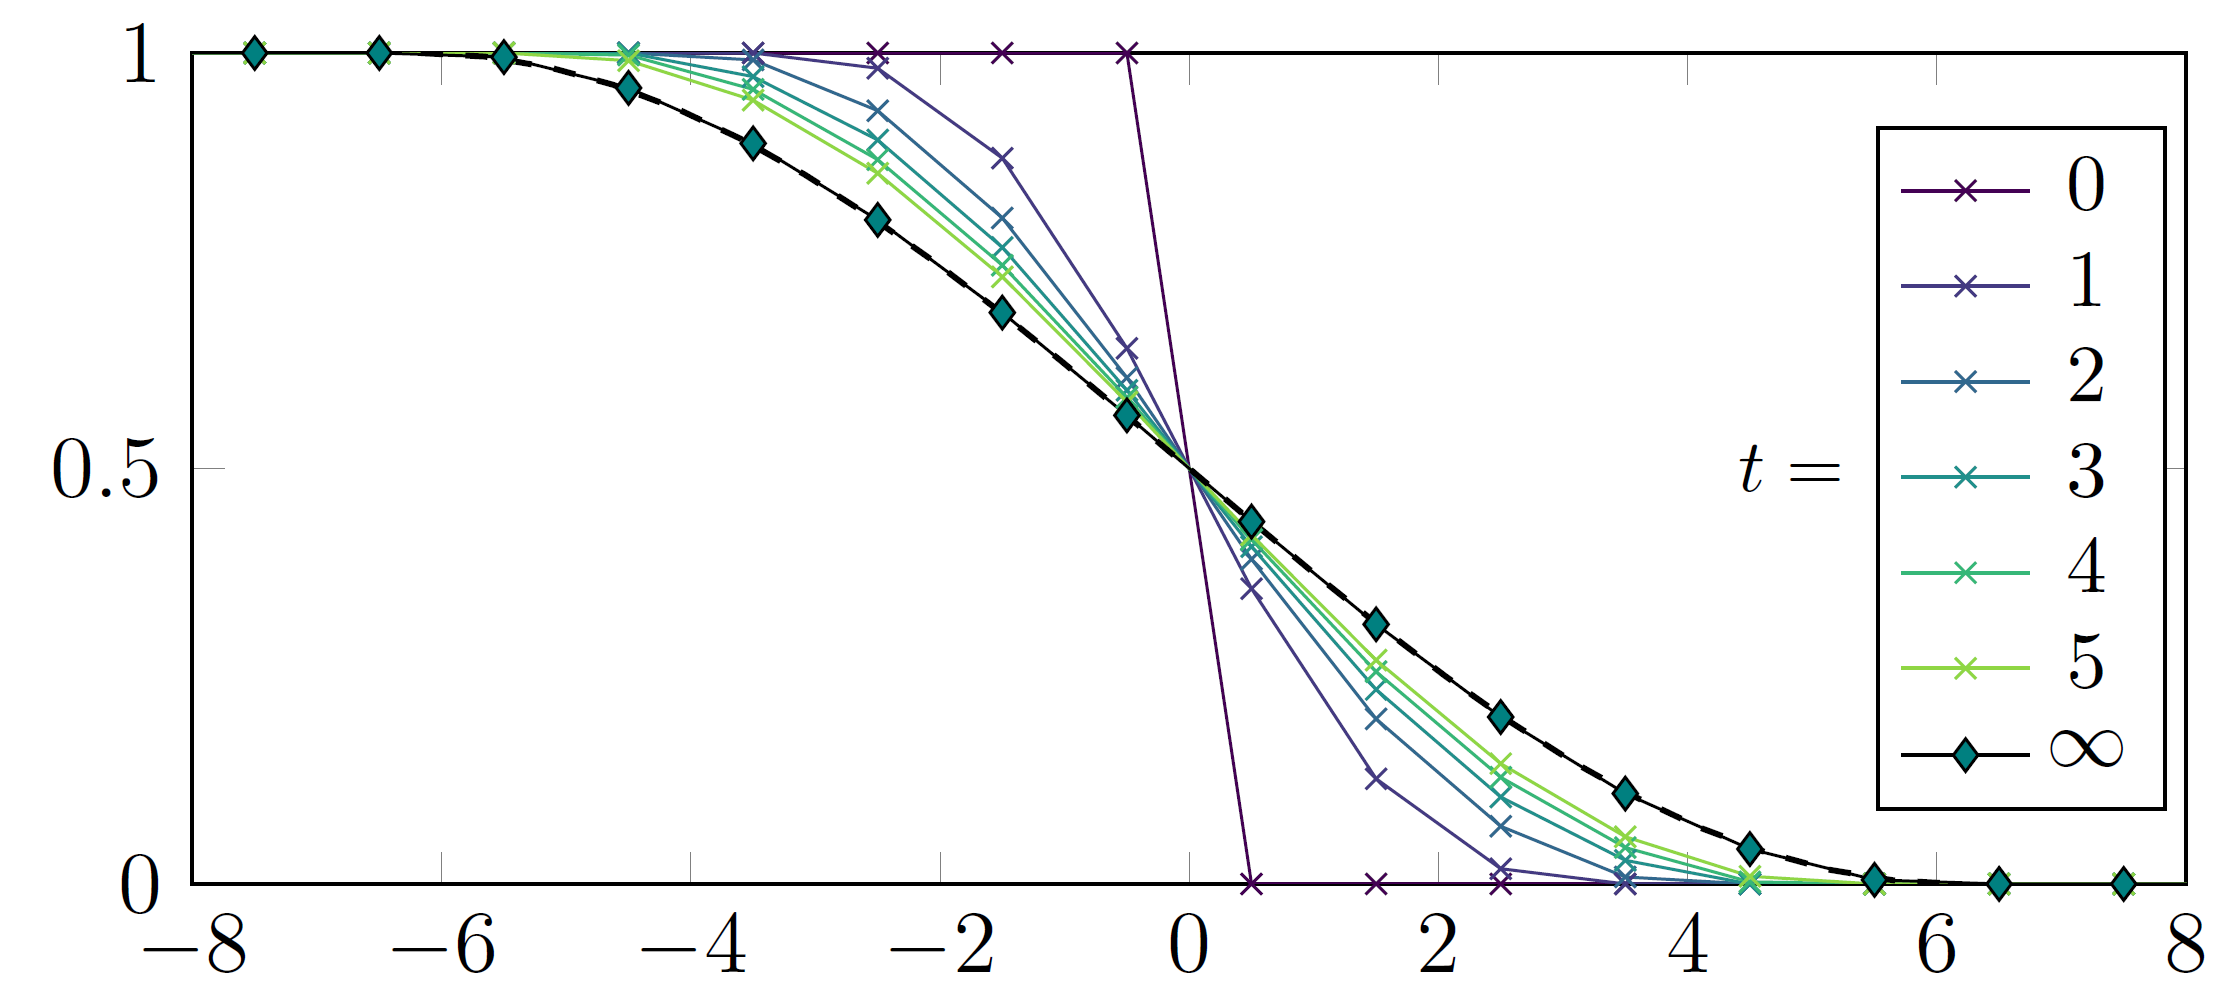

In this case, it doesn't matter if we are solving Cahn-Hilliard or Allen-Cahn dynamics as they lead to the same steady state. The one-dimensional steady-state solution given by $\dot{\phi}=0$ yields

$$\epsilon\nabla^2\phi = \frac{9}{\epsilon}\phi(1-2\phi)(1-\phi)\to \epsilon\left(\frac{\partial\phi}{\partial x}\right)^2=\frac{9}{\epsilon}\phi^2(1-\phi)^2\to \mathrm{d}x = \frac{\epsilon}{3\phi(1-\phi)}\mathrm{d} \phi$$

The prefactors of the two energy terms in the energy functional are chosen such that the surface energy of a flat interface $\gamma$ equals the parameter $\gamma_0$ as it is defined as the excess Gibbs free energy across the diffuse region

$$\gamma = \gamma_0\int_{-\infty}^\infty \epsilon|\nabla\phi|^2+\frac{9}{\epsilon}\phi^2(1-\phi)^2 \mathrm{d}{x} = 2\gamma_0\int_0^1 3\phi(1-\phi) \mathrm{d}{\phi}=\gamma_0$$

The double-well potential in combination with the gradient term, results in the equilibrium profile 

$$\phi=\frac{1}{2} + \frac{1}{2}\tanh\left(\frac{3x}{2\epsilon}\right)$$

and the interfacial width can be defined by the linear tangent fit in $\phi=0.5$ such that
$l_\text{int}=\mathrm{d}{x}/\mathrm{d}{\phi}\big|_{\phi=0.5}=4\epsilon/3$.

We can use this knowledge to test the numerical solution of the two-phase Cahn-Hilliard and Allen-Cahn solvers as well as the multi-phase Allen-Cahn solver against the analytical solution.

Allen-Cahn L2 error:   0.0130
Cahn-Hilliard L2 error: 0.0296
Multi-Phase L2 error: 0.0130


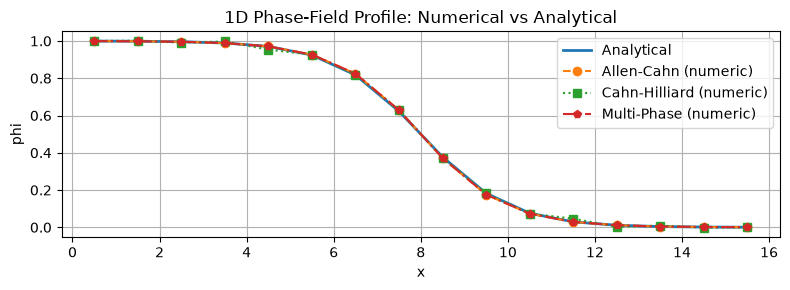

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import evoxels as evo

# Setup
Nx = 16
vf = evo.VoxelFields((Nx, 1, 1), domain_size=(Nx, 1, 1))
phi = np.zeros((Nx, 1, 1), dtype=np.float32)
phi[: Nx // 2] = 1.0
vf.add_field("phi1", phi.copy())
vf.add_field("phi2", phi.copy())
vf.add_field("phia", phi.copy())
vf.add_field("phib", (1-phi).copy())

# Parameters
eps = 3.0
steps = 20
dt = 0.5
bcs = ('neumann','periodic','periodic')

evo.run_allen_cahn_solver(
    vf, "phi1", backend="torch", time_increment=dt, frames=1, max_iters=steps,
    eps=eps, curvature=1.0, bc=bcs, jit=False, verbose=False,
)
evo.run_cahn_hilliard_solver(
    vf, "phi2", backend="torch", time_increment=dt, frames=1, max_iters=steps,
    eps=eps, bc=bcs, jit=False, verbose=False,
)
evo.run_multi_phase_solver(
    vf, ("phia", "phib"), backend="torch", from_labels=False,
    time_increment=dt, frames=1, max_iters=steps,
    eps=eps, M=1.0, bc=bcs, jit=False, verbose=False,
)

# Extract results
phi1_numeric = vf.fields["phi1"].squeeze()
phi2_numeric = vf.fields["phi2"].squeeze()
phi3_numeric = vf.fields["phia"].squeeze()

# Analytical profile
x = np.arange(Nx) + 0.5
phi_analytic = 0.5 - 0.5 * np.tanh(3 * (x - 0.5 * Nx) / (2 * eps))

# Errors
L2_error1 = np.linalg.norm(phi1_numeric - phi_analytic)
L2_error2 = np.linalg.norm(phi2_numeric - phi_analytic)
L2_error3 = np.linalg.norm(phi3_numeric - phi_analytic)

print(f"Allen-Cahn L2 error:   {L2_error1:.4f}")
print(f"Cahn-Hilliard L2 error: {L2_error2:.4f}")
print(f"Multi-Phase L2 error: {L2_error3:.4f}")

# Plot
plt.figure(figsize=(8, 3))
plt.plot(x, phi_analytic, label="Analytical", linewidth=2)
plt.plot(x, phi1_numeric, "o--", label="Allen-Cahn (numeric)")
plt.plot(x, phi2_numeric, "s:", label="Cahn-Hilliard (numeric)")
plt.plot(x, phi3_numeric, "p-.", label="Multi-Phase (numeric)")
plt.xlabel("x")
plt.ylabel("phi")
plt.title("1D Phase-Field Profile: Numerical vs Analytical")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The 1D equilibrium profile is used for continuous integration testing of the ``evoxels`` package (``test_1D_analytical_tanh_profile`` function in ``test_solvers.py``).

## 1D moving interface

[Rate-reaction theory](https://link.springer.com/article/10.1007/BF03397362) relates the interface normal velocity $v_n$ to a driving force. In the current setup we consider the superposition of two effects: A capillary driving force resulting from an isotropic grain-boundary energy $\gamma_{0}$ and a constant bulk driving force $\Delta f$.
This leads to the equation

$$v_n = M_{\mathrm{GB}} \left(\Delta f - \gamma_{0} \kappa \right)$$

where $M_{\mathrm{GB}}$ is the constant mobility of the grain boundary and $\kappa$ its curvature. For a 1D flat interface, the curvature equals zero and, thus, the interface velocity is solely determined by the driving force.

As discussed by [Hoffrogge et al.](https://iopscience.iop.org/article/10.1088/1361-651X/ad8d6f), the velocity error of a moving interface approximated by the phase-field method is determined by the ratio of interface-stabilizing forces versus bulk driving forces - more specifically, the dimensionless quantity

$$\tilde{p}_{\mathrm{PF}}\equiv\frac{\epsilon}{\gamma_0}\Delta f.$$

Here, $\epsilon$ scales the width of the diffuse interface, $\gamma_0$ is the interfacial energy and $\Delta f$ denotes the driving force acting on the phase boundary.
In general, the interfacial thickness $\eta$ (for double well $\eta=4\epsilon/3$) should be much smaller than the domain size which implies that the phasefield-specific driving force $\tilde{p}_{\mathrm{PF}}$ is always smaller than the physical driving force $\tilde{p}=L\Delta f/\gamma_0$. Therefore, the bulk driving force can only be large with respect to the interface stabilizing force when we are far in the large driving force regime.

``TBD``

## 3D Shrinking sphere benchmark

The shrinking-sphere benchmark is the radially symmetric sharp-interface solution of curvature-driven motion.
This benchmark is useful because it isolates a single kinetic mechanism: curvature-driven interface motion. A planar interface with zero driving force should remain stationary, while a curved interface has a known collapse law. That makes it a clean check of both kinetics and discretization error.
In the sharp-interface limit of Allen-Cahn-type phase-field models, the normal velocity is proportional to the mean curvature,

$$
v_n = -M_{\mathrm{GB}}\gamma_{0} \kappa,
$$

where $M_{\mathrm{GB}}$ is the effective kinetic coefficient after nondimensionalisation and parameter matching. For a sphere of radius $R(t)$, the mean curvature is $\kappa = 2/R$ which then leads to the time evolution

$$R(t) = \sqrt{R_0^2 - 4 M_{\mathrm{GB}}\gamma_{0} t}.$$

Numerically, the benchmark compares the measured radius against the formula above or - as this can be more directly obtained from the simulation - compares the volume fraction of the sphere to its analytical counterpart

$$f = \frac{4\pi R(t)^3}{3V} = \frac{4\pi(R_0^2 - 4 M_{\mathrm{GB}}\gamma_{0}t)^{3/2}}{3V}.$$

Note that $f^{2/3}$ is linear in time $t$ and hence, $\partial f^{2/3}/\partial t$ can be used as a constant to quantify the error resulting from the interfacial resolution given by the parameter $\epsilon$.

Typical uses in the literature are:

- Allen and Cahn (1979), who derived curvature-proportional interface motion for antiphase boundaries, providing the physical basis for this benchmark.
- Bronsard and Kohn (1991), who established mean-curvature motion as the sharp-interface limit of Ginzburg-Landau / Allen-Cahn dynamics.
- [Eiken](https://iopscience.iop.org/article/10.1088/1757-899X/33/1/012105) (2012), uses this benchmark to validate finite difference correction factors for discrete Laplacian in combination with a double-obstacle potential.

``TBD``